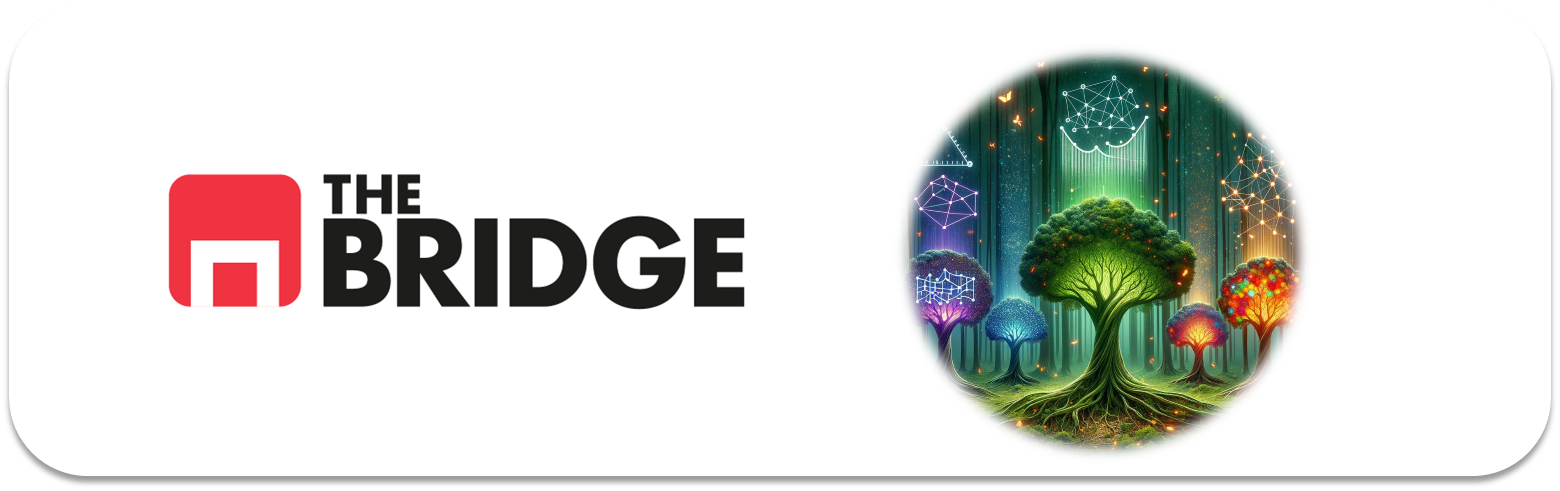

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import bootcampviztools as gv


### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

### **1. Cargamos el dataset**

In [143]:
# Al cargar el dataset nos damos cuenta que debemos meter un separador para diferencia columnas
# Instacionamos el dataset en un dataframe y cargamos varios registros de prueba

df = pd.read_csv('data/bank-full.csv', sep=';')
df.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [144]:
df.info() # Aquí observamos el volumen total de variables

# 1. No tiene valores nulos. 
# 2. Tenemos una mezcla de variables categóricas y variables numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [145]:
df.describe() # Aquí mostramos los valores descriptivos de las variables, en este caso numéricas

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### **2. Identificar el target y ver su distribución**

De todas las variables que tenemos en el dataset, la única que no se explica en la descripción es la variables `y`

In [146]:
# Analizamos los valores de la variable y 
# Tenemos casi 40k registros con un valor de "no" y 5,2k con un valor de "yes"
# Esto podría referirse sin especificarlo a la contratación del depósito. 
# El resto de variables son elementos relacionados con la tipología de cliente y el contacto del banco con ellos 

df.y.value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [147]:
df.y.value_counts()/len(df)*100 # Valores porcentuales. 

# El 88% de los clientes que reciben el contacto del banco no contratan el depósito. 
# El 11% sí contratan el servicio. 

y
no     88.30152
yes    11.69848
Name: count, dtype: float64

### **3. Valores "unknown"**

- De la revisión de .info() y .head(20) se ven dos cosas interesantes. 
- En principio no hay valores nulos. 
- Hay variables que tienen `valores == "unknown"`

In [148]:
# Bucle for para saber el porcentaje de valores descocidos por variable
# Es relevante porque no disponer de datos de algunas variables es relevante
# poutcome tiene un 81% de valores unknown --> es el marcado del resultado de la llamada previa
# contact, con un 28% de estos valores, es el tipo de contacto con el cliente (teléfono, móvil o desconocido)

for col in df.select_dtypes(include='object').columns:
    unknown_value = (df[col] == 'unknown').sum()
    if unknown_value > 0:
        vars_unknown = (unknown_value/len(df)) * 100
        print(f"{col}: {unknown_value} valores 'unknown' -> {vars_unknown:.2f}%")

job: 288 valores 'unknown' -> 0.64%
education: 1857 valores 'unknown' -> 4.11%
contact: 13020 valores 'unknown' -> 28.80%
poutcome: 36959 valores 'unknown' -> 81.75%


### **4. Hacemos un mini-EDA de las variables**

In [149]:
# Listamos todas las variables por tipología: numéricas y categóricas

cols_nums = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Variables numéricas: {cols_nums}")

cols_cats = df.select_dtypes(include=['object']).columns.tolist()
cols_cats.remove('y')
print(f"Variables categóricas: {cols_cats}")

Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


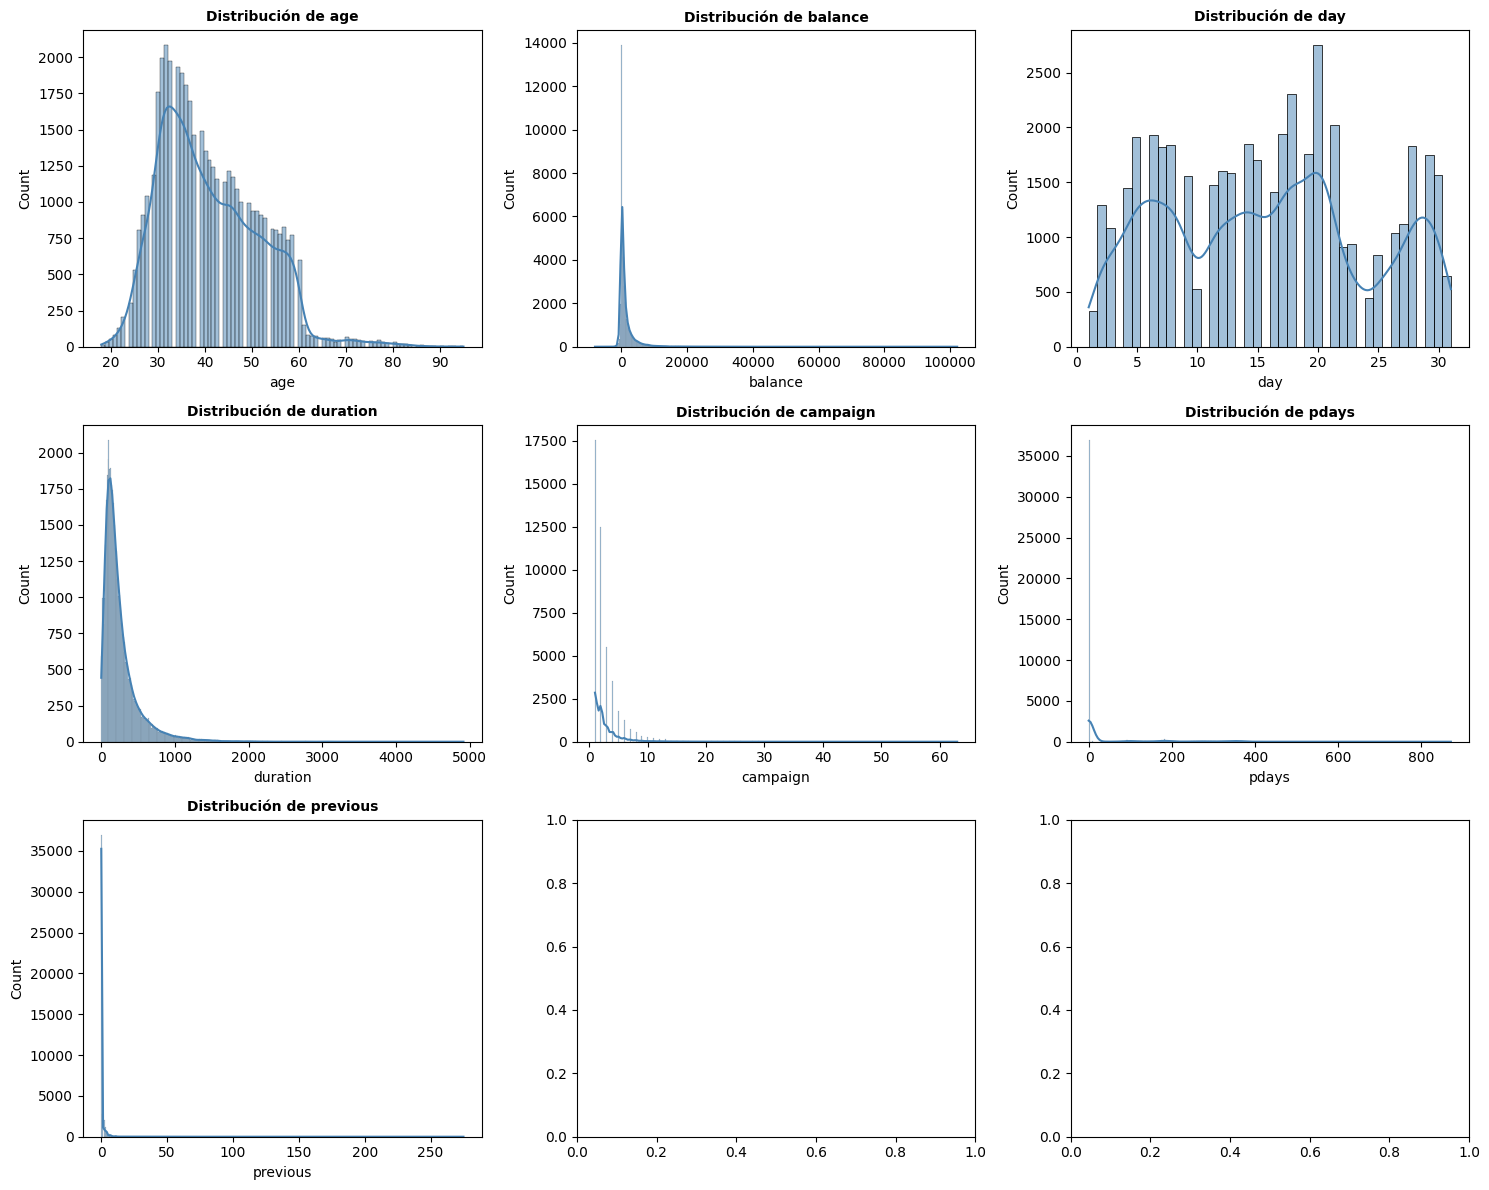

In [150]:
# Distribuciones de variables numéricas

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_nums[:9]):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


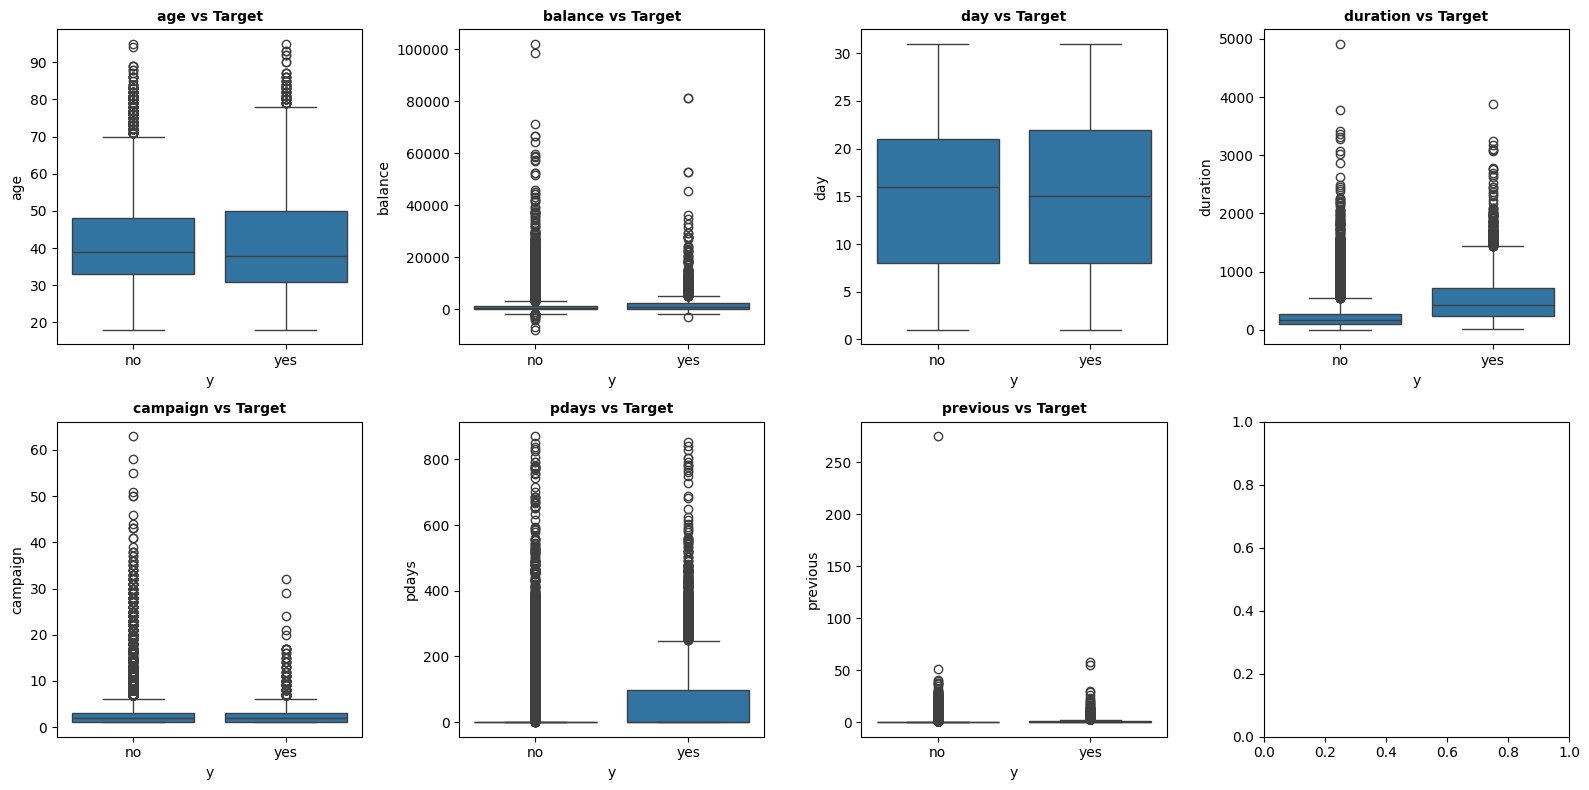

In [151]:
# Comparación de percentiles y outliers entre cada una de las variables categóricas y el target (y)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_nums[:8]):
    sns.boxplot(data=df, x='y', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Target', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Algunas ideas a partir de las visualizaciones:  

- 'duration' (duración de llamada): muestra gran diferencia entre clases
- 'balance' (saldo): parece ligeramente mayor en quienes se suscriben
- 'pdays': tiene muchos valores -1 (cliente que no fueron contactados previamente)

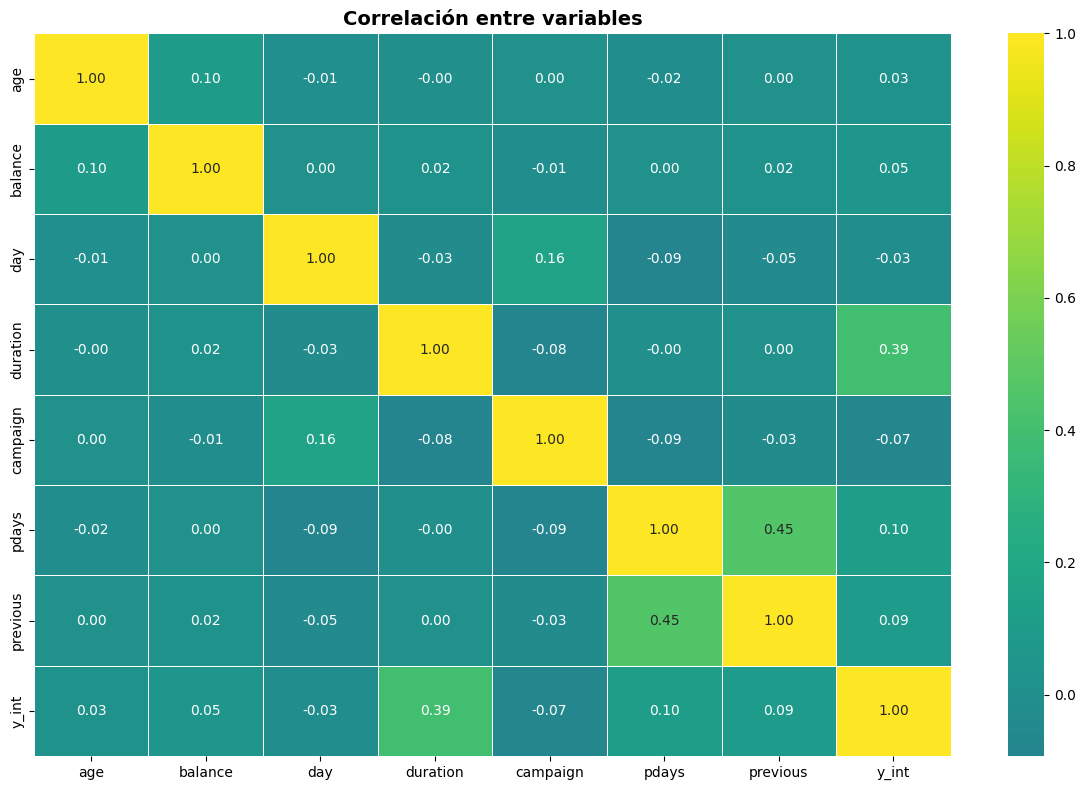

In [152]:
# Creamos un df de convertimos a la variable y a una variable entera
# Al pasar la variable target a int, asocia yes == 1 y no == 0
# Esto va a permitir comparar numéricas con target porque target ya es numérica 

df_corr = df.copy()
df_corr['y_int'] = (df_corr['y'] == 'yes').astype(int)

plt.figure(figsize=(12, 8))
corr_matrix = df_corr[cols_nums + ['y_int']].corr()
sns.heatmap(corr_matrix, annot=True, cmap = "viridis", center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlación entre variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- Aquí puede verse la enorme correlación positiva que existe entre la duración de la llamada y la contratación final. 
- Impulsar que las llamadas se alarguen en el tiempo puede ser un factor de cierre de operación relevante. 
- Luego tienen un correlación positiva muy fuerte `pdays` (volumen de días tras último contacto) y `prevoius` (número de contactos previous con cliente).
- Lógicamente cuando las variables de días desde el último contacto y numero de contactos previos tienen un relación positiva directa. 

### **5. Split entre el modelo de entrenamiento y el modelo de test**

In [153]:
# Separamos X == features de la vairable target == y
# Convertimos y de nuevo en una variable entera 
# Hacemos el split y estratificamos por la variable target para que el volumen de datos sea proporcional a clientes que contratan y no contratan 

X = df.drop('y', axis=1)
y = df['y']

y = (y == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

In [154]:
# Vemos algunas proporciones de la variable target en los datasets de entramiento y test

print("Distribución del target en train:")
print(y_train.value_counts(normalize=True) * 100)

print("Distribución del target en test:")
print(y_test.value_counts(normalize=True) * 100)

print("Las variaciones entre los distintos conjuntos de datos son mínimas gracias a la estratificación por el target")

Distribución del target en train:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64
Distribución del target en test:
y
0    88.300343
1    11.699657
Name: proportion, dtype: float64
Las variaciones entre los distintos conjuntos de datos son mínimas gracias a la estratificación por el target


### **6. Modelo de Regresión logística y Árbol de decisión**

In [155]:
print(f"Columnas categóricas a codificar: {cols_cats}")
print(f"Columnas numéricas: {cols_nums}")

Columnas categóricas a codificar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Columnas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [156]:
# Aplicamos One-Hot Encoding a variables categóricas
# Y escalamos las variables numéricas después de lo visto en los histogramas 

X_train_encoded = pd.get_dummies(X_train, columns=cols_cats, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cols_cats, drop_first=True)

scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[cols_nums] = scaler.fit_transform(X_train_encoded[cols_nums])
X_test_scaled[cols_nums] = scaler.transform(X_test_encoded[cols_nums])


#### **Modelo de Regresión logística**

In [157]:
log_reg = LogisticRegression(random_state=42, max_iter=10000)
log_reg.fit(X_train_scaled, y_train) 

LogisticRegression(max_iter=10000, random_state=42)

In [158]:
y_train_log_predict = log_reg.predict(X_train_scaled)
y_test_log_predict = log_reg.predict(X_test_scaled)

In [159]:
y_train_log_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [160]:
# Métricas en train
print("Métricas en train:")
print(f"- Accuracy: {accuracy_score(y_train, y_train_log_predict)}")
print(f"- Precision: {precision_score(y_train, y_train_log_predict)}")
print(f"- Recall: {recall_score(y_train, y_train_log_predict)}")
print(f"- F1-Score: {f1_score(y_train, y_train_log_predict)}")
print(f"- AUC-ROC: {roc_auc_score(y_train, y_train_log_predict)}")

# Métricas de test
print("Métricas en test:")
print(f"- Accuracy: {accuracy_score(y_test, y_test_log_predict)}")
print(f"- Precision: {precision_score(y_test, y_test_log_predict)}")
print(f"- Recall: {recall_score(y_test, y_test_log_predict)}")
print(f"- F1-Score: {f1_score(y_test, y_test_log_predict)}")
print(f"- AUC-ROC: {roc_auc_score(y_test, y_test_log_predict)}")

Métricas en train:
- Accuracy: 0.9020128290201282
- Precision: 0.6541049798115747
- Recall: 0.3445993854880643
- F1-Score: 0.45139318885448915
- AUC-ROC: 0.6602290536733617
Métricas en test:
- Accuracy: 0.9015813336282207
- Precision: 0.6473684210526316
- Recall: 0.3487712665406427
- F1-Score: 0.4533169533169533
- AUC-ROC: 0.6617995343348173


#### **Modelo de Árbol de decisión**

In [161]:
# Crear modelo con el Árbol de decisión

tree_reg = DecisionTreeClassifier(random_state=42)
tree_reg.fit(X_train_encoded, y_train)

y_train_tree_predict = tree_reg.predict(X_train_encoded)
y_test_tree_predict = tree_reg.predict(X_test_encoded)

y_train_tree_proba = tree_reg.predict_proba(X_train_encoded)[:, 1]
y_test_tree_proba = tree_reg.predict_proba(X_test_encoded)[:, 1]

In [162]:
# Métricas en train del árbol de decisión 

print("Métricas en train del árbol de decisión:")
print(f"- Accuracy: {accuracy_score(y_train, y_train_tree_predict)}")
print(f"- Precision: {precision_score(y_train, y_train_tree_predict)}")
print(f"- Recall: {recall_score(y_train, y_train_tree_predict)}")
print(f"- F1-Score: {f1_score(y_train, y_train_tree_predict)}")
print(f"- AUC-ROC: {roc_auc_score(y_train, y_train_tree_predict)}")

# Métricas de test del árbol de decisión 
print("Métricas en test del árbol de decisión:")
print(f"- Accuracy: {accuracy_score(y_test, y_test_tree_predict)}")
print(f"- Precision: {precision_score(y_test, y_test_tree_predict)}")
print(f"- Recall: {recall_score(y_test, y_test_tree_predict)}")
print(f"- F1-Score: {f1_score(y_test, y_test_tree_predict)}")
print(f"- AUC-ROC: {roc_auc_score(y_test, y_test_tree_predict)}")
print(f"Profundidad del árbol: {tree_reg.get_depth()}")
print(f"Número de hojas: {tree_reg.get_n_leaves()}")

Métricas en train del árbol de decisión:
- Accuracy: 1.0
- Precision: 1.0
- Recall: 1.0
- F1-Score: 1.0
- AUC-ROC: 1.0
Métricas en test del árbol de decisión:
- Accuracy: 0.8775848722768993
- Precision: 0.47782805429864256
- Recall: 0.499054820415879
- F1-Score: 0.4882108183079057
- AUC-ROC: 0.7133971660000497
Profundidad del árbol: 35
Número de hojas: 2991


### **Comparamos los dos modelos: regresión logística y árbol de decisión**

In [163]:
# Métricas de test de regresión logística

print("Métricas en test de la regresión logística:")
print(f"- Accuracy: {accuracy_score(y_test, y_test_log_predict)}")
print(f"- Precision: {precision_score(y_test, y_test_log_predict)}")
print(f"- Recall: {recall_score(y_test, y_test_log_predict)}")
print(f"- F1-Score: {f1_score(y_test, y_test_log_predict)}")
print(f"- AUC-ROC: {roc_auc_score(y_test, y_test_log_predict)}")

# Métricas de test de árbol de decisión 

print("Métricas en test del árbol de decisión:")
print(f"- Accuracy: {accuracy_score(y_test, y_test_tree_predict)}")
print(f"- Precision: {precision_score(y_test, y_test_tree_predict)}")
print(f"- Recall: {recall_score(y_test, y_test_tree_predict)}")
print(f"- F1-Score: {f1_score(y_test, y_test_tree_predict)}")
print(f"- AUC-ROC: {roc_auc_score(y_test, y_test_tree_predict)}")


Métricas en test de la regresión logística:
- Accuracy: 0.9015813336282207
- Precision: 0.6473684210526316
- Recall: 0.3487712665406427
- F1-Score: 0.4533169533169533
- AUC-ROC: 0.6617995343348173
Métricas en test del árbol de decisión:
- Accuracy: 0.8775848722768993
- Precision: 0.47782805429864256
- Recall: 0.499054820415879
- F1-Score: 0.4882108183079057
- AUC-ROC: 0.7133971660000497


In [166]:
print(classification_report(y_test, y_test_log_predict))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [165]:
print(classification_report(y_test, y_test_tree_predict))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.48      0.50      0.49      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



Conclusiones: 

- Mayor AUC-ROC (0.71 vs 0.66): el Árbol de decisión es mejor discriminando entre quién comprará el depósito.
- Mejor Recall (0.49 vs 0.34): el Árbol de decisión captura casi el 50% de los compradores reales, mientras que la Regresión Logística ignora al 65% de ellos. La idea aquí es no perder clientes potenciales. 
- F1-Score superior: el Árbol de decisión demuestra ser un modelo más robusto para este conjunto de datos desbalanceado.